In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

/glade/derecho/scratch/ihtam/tmp/ipykernel_115199/1496010805.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 13.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 11,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

def save_to_pickle(filepath,data):
    with open(filepath, 'wb') as handle:
        pickle.dump(data, handle)

def open_pickle(filepath):
    with open(filepath, 'rb') as handle:
        data = pickle.load(handle)
    return data

/glade/derecho/scratch/ihtam/tmp/ipykernel_115199/3257663514.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [5]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

RTHRATLW_dict = open_pickle('./parallel/store/RTHRATLW_dict_z.pkl')

In [10]:
RTHRATLW_axim = np.mean(RTHRATLW_dict['CTRL']['varpol'],axis=-1)

/glade/derecho/scratch/ihtam/tmp/ipykernel_115199/1105928626.py:1: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(np.linspace(0,600,200),[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000],


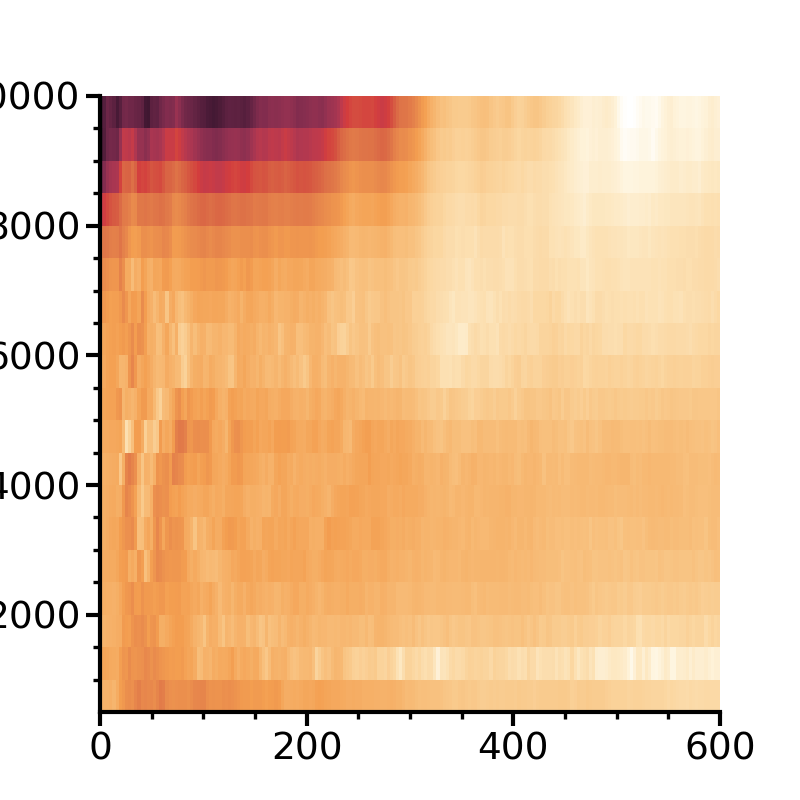

In [18]:
plt.pcolormesh(np.linspace(0,600,200),[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000],
               RTHRATLW_axim[20,...])

In [16]:
np.linspace(0,600,200).shape

(200,)